In [35]:
import numpy as np
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
from DESolver import DESolver
from problems_ODEs import ProblemsODE
from problems_PDEs import ProblemsPDE

import seaborn as sns
sns.set_context("talk", font_scale=1.) # "talk"

CFL max = 0.081; CFL min = 0.081
Solving AdvectionDiffusion1D by using MPRK2-IMEXb


/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Mass ini = 0.9999999999999999 and mass end = 1.0000000000000022


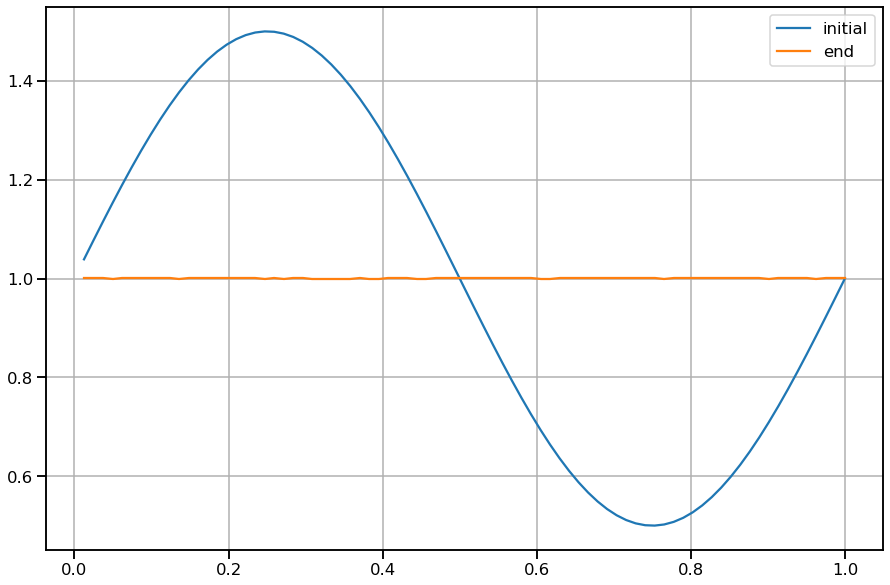

In [38]:
solver=DESolver()
solver.set_info(0)

mx=81

Flux_c=1.
Flux_cv=np.zeros((1,mx))
Flux_cv[:]=1.
Flux_cv[0,5:int(mx/2.)-5]=1.

pde_problem_setup={'mx':mx,'n':1,'Flux':'linear-advection','Flux_cv':Flux_cv,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':1.}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')
solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

solver.set_rhs(rhs_e)
solver.set_rhs({'mr_explicit_fast':problem.rhs_e_fast,'mr_explicit_slow':problem.rhs_e_slow,'mr_implicit':problem.rhs_mr_implicit})
solver.set_rhs({'imex_explicit':problem.rhs_e,'imex_implicit':problem.rhs_mr_implicit})

#solver.set_method('RK4')
solver.set_method('MPRK2-IMEXb')
#solver.set_method('MPRK2-RK3SSPHig-IMEX')
#solver.set_method('ARK2c')
#solver.set_method('ARK-IMEX-MR4-Slow')
#solver.set_method('ARK-IMEX-MR4')

#if(rhs_i is not None):
#    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
#else:
#    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.001    
problem_setup['T_DURATION']['end']=1.
print("CFL max = {:g}; CFL min = {:g}".format(np.max(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx'],np.min(pde_problem_setup['Flux_cv'])*problem_setup['DT']/problem_setup['context']['dx']))
mass_ini=problem.TotalMass(problem.unvectorize(u_ini,problem_setup['context']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u=solver.get_trajectory()
u_end=solver.get_solution()
mass_end=problem.TotalMass(problem.unvectorize(u_end,problem_setup['context']))
#u=solver.get_solution()

print("Mass ini = {:} and mass end = {:}".format(mass_ini,mass_end))

unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()


In [39]:
solver.view_complete_status()

------------------------------------------
Current Method
Selected method type: IMEX-MRK
Method coefficients:
A_f =
[[0.   0.   0.   0.  ]
 [0.5  0.   0.   0.  ]
 [0.25 0.25 0.   0.  ]
 [0.25 0.25 0.5  0.  ]]
b_f =
[0.25 0.25 0.25 0.25]
c_f =
[0.  0.5 0.5 1. ]
A_s =
[[0. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 1. 0.]]
b_s =
[0.25 0.25 0.25 0.25]
c_s =
[0. 1. 0. 1.]
At =
[[0.  0.  0.  0. ]
 [0.  0.  0.  0. ]
 [0.5 0.  0.  0. ]
 [1.  0.5 1.  1. ]]
bt =
[0.25 0.25 0.25 0.25]
ct =
[0.  0.  0.5 3.5]
------------------------------------------


['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'MPRK2-IMEX',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX']

In [13]:
solver.view_complete_status()

------------------------------------------
Current Method
Selected method type: IMEX-MRK
Method coefficients:
A_f =
[[0.         0.         0.         0.         0.         0.        ]
 [0.5        0.         0.         0.         0.         0.        ]
 [0.125      0.125      0.         0.         0.         0.        ]
 [0.08333333 0.08333333 0.33333333 0.         0.         0.        ]
 [0.08333333 0.08333333 0.33333333 0.5        0.         0.        ]
 [0.08333333 0.08333333 0.33333333 0.125      0.125      0.        ]]
b_f =
[0.08333333 0.08333333 0.33333333 0.08333333 0.08333333 0.33333333]
c_f =
[0.   0.5  0.25 0.5  1.   0.75]
A_s =
[[0.   0.   0.   0.   0.   0.  ]
 [1.   0.   0.   0.   0.   0.  ]
 [0.25 0.25 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   1.   0.   0.  ]
 [0.   0.   0.   0.25 0.25 0.  ]]
b_s =
[0.08333333 0.08333333 0.33333333 0.08333333 0.08333333 0.33333333]
c_s =
[0.  1.  0.5 0.  1.  0.5]
At =
[[ 0.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. 

['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'MPRK2-IMEX',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX']

CFL = 0.162
Solving AdvectionDiffusion1D by using ARK2e
[[0.         0.         0.        ]
 [0.29289322 0.29289322 0.        ]
 [0.35355339 0.35355339 0.29289322]] [0.35355339 0.35355339 0.29289322]
X  in: 14709.869144257564
X out: 6.92749812884821e-10
X  in: 7362.61022128303
X out: 7.855334641957734e-10
Norm of KE_0=19.98796108190764
** KI_0=[-152887.22224188 -304854.96273994 -454989.26962113]
Norm of KE_1=19.97067616093616
** KI_1=[152761.26578391 304597.53316903 454601.91514969]
Norm of KE_2=0.012209373618078913
** KI_2=[ 75.77270114 168.74914789 260.71071625]
[[0.         0.         0.        ]
 [0.29289322 0.29289322 0.        ]
 [0.35355339 0.35355339 0.29289322]] [0.35355339 0.35355339 0.29289322]
X  in: 174.55049547138282
X out: 7.901206351220292e-10
X  in: 87.36632865215614
X out: 7.896686803724007e-10
Norm of KE_0=0.23718147835878328
** KI_0=[23409.58727622 23361.84959745 23174.21138191]
Norm of KE_1=0.2369763717403776
** KI_1=[-23389.34460223 -23341.64211011 -23154.16061115

/opt/local/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


X  in: 0.0010969480679343738
X out: 1.0488581742833953e-09
Norm of KE_0=1.2810615719159076e-07
** KI_0=[-0.07519817  0.0780015  -0.21410847]
Norm of KE_1=1.2810588938785717e-07
** KI_1=[ 0.07519817 -0.07800174  0.21410799]
Norm of KE_2=4.933765416978814e-13
** KI_2=[1.19209290e-07 0.00000000e+00 2.38418579e-07]
[[0.         0.         0.        ]
 [0.29289322 0.29289322 0.        ]
 [0.35355339 0.35355339 0.29289322]] [0.35355339 0.35355339 0.29289322]
X  in: 0.002419431808723549
X out: 9.970865804322072e-10
X  in: 0.0012097176602621235
X out: 1.1657620311723677e-09
Norm of KE_0=1.4233801929966623e-07
** KI_0=[-0.29641867  0.21545053  0.02608943]
Norm of KE_1=1.4233780020028984e-07
** KI_1=[ 0.29641819 -0.21545029 -0.02608943]
Norm of KE_2=7.639123143429047e-13
** KI_2=[ 3.57627869e-07 -2.38418579e-07  0.00000000e+00]
[[0.         0.         0.        ]
 [0.29289322 0.29289322 0.        ]
 [0.35355339 0.35355339 0.29289322]] [0.35355339 0.35355339 0.29289322]
X  in: 0.00287955426880498

X out: 9.580102490642566e-10
Norm of KE_0=1.3054847558969294e-07
** KI_0=[ 0.17420959 -0.05591035 -0.06284738]
Norm of KE_1=1.3054825845860224e-07
** KI_1=[-0.174209    0.05591011  0.06284714]
Norm of KE_2=3.746882802104717e-13
** KI_2=[-5.96046448e-07  4.76837158e-07  0.00000000e+00]
[[0.         0.         0.        ]
 [0.29289322 0.29289322 0.        ]
 [0.35355339 0.35355339 0.29289322]] [0.35355339 0.35355339 0.29289322]
X  in: 0.0022064309211290716
X out: 9.547220138371127e-10
X  in: 0.00110321705699125
X out: 8.710617773350637e-10
Norm of KE_0=1.3068981005321383e-07
** KI_0=[ 0.10615921 -0.26438546  0.23102736]
Norm of KE_1=1.3068958726525578e-07
** KI_1=[-0.10615909  0.26438522 -0.23102689]
Norm of KE_2=6.494773949346792e-13
** KI_2=[ 0.00000000e+00  0.00000000e+00 -2.38418579e-07]
[[0.         0.         0.        ]
 [0.29289322 0.29289322 0.        ]
 [0.35355339 0.35355339 0.29289322]] [0.35355339 0.35355339 0.29289322]
X  in: 0.0019002556607434643
X out: 1.0145281742058146e

X  in: 0.0010414534656022173
X out: 1.1708485686969637e-09
Norm of KE_0=1.2107972742681263e-07
** KI_0=[-0.2760911   0.04981613  0.2944715 ]
Norm of KE_1=1.2107950702811957e-07
** KI_1=[ 0.27609086 -0.04981589 -0.29447055]
Norm of KE_2=4.599537018173275e-13
** KI_2=[ 0.00000000e+00 -2.38418579e-07 -2.38418579e-07]
[[0.         0.         0.        ]
 [0.29289322 0.29289322 0.        ]
 [0.35355339 0.35355339 0.29289322]] [0.35355339 0.35355339 0.29289322]
X  in: 0.0029400389832734903
X out: 8.596051917882254e-10
X  in: 0.0014700216159714567
X out: 9.794828924031777e-10
Norm of KE_0=1.6597928137840775e-07
** KI_0=[ 0.08420587  0.25205874 -0.62836528]
Norm of KE_1=1.659789914429797e-07
** KI_1=[-0.08420575 -0.25205851  0.62836409]
Norm of KE_2=5.268280477581751e-13
** KI_2=[0.00000000e+00 0.00000000e+00 4.76837158e-07]
[[0.         0.         0.        ]
 [0.29289322 0.29289322 0.        ]
 [0.35355339 0.35355339 0.29289322]] [0.35355339 0.35355339 0.29289322]
X  in: 0.002856118146969718

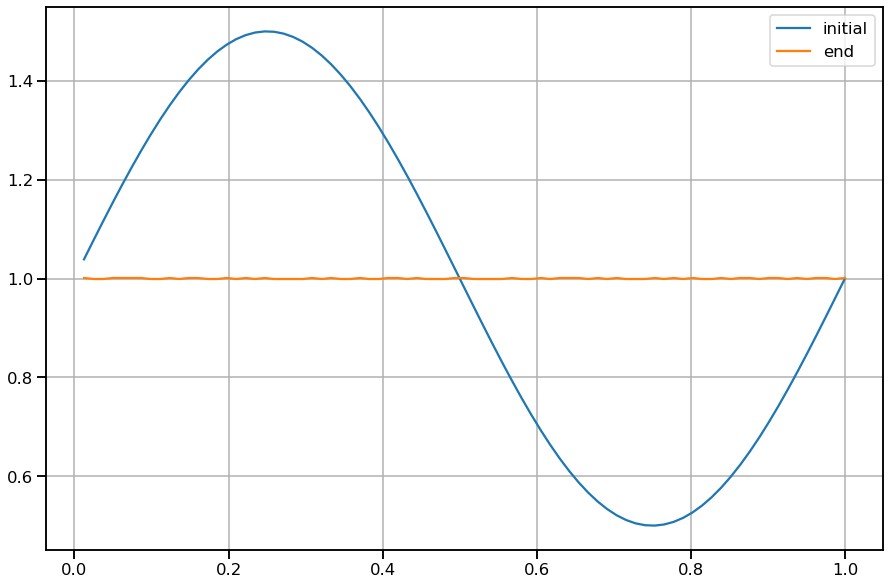

In [7]:
solver=DESolver()
solver.set_info(0)

pde_problem_setup={'mx':81,'n':1,'Flux':'linear-advection','Flux_c':1.0,'BC':'periodic',
                   'x_min':0.,'x_max':1.,'kappa':100000.}
rhs_e, rhs_i, u_ini, problem_setup, problem= ProblemsPDE('AdvectionDiffusion1D',pde_problem_setup)#('Navier-Stokes2D')
solver.setup(keep_history=True)
solver.set_function_context(problem_setup['context'])
solver.set_initial_solution(u_ini)

solver.set_rhs(rhs_e)
solver.set_rhs({'mr_explicit_fast':problem.rhs_e_fast,'mr_explicit_slow':problem.rhs_e_slow,'mr_implicit':problem.rhs_mr_implicit})
solver.set_rhs({'imex_explicit':problem.rhs_e,'imex_implicit':problem.rhs_mr_implicit})

#solver.set_method('RK4')
#solver.set_method('MPRK2-IMEX')
solver.set_method('ARK2e')
#solver.set_method('ARK-IMEX-MR4-Slow')
#solver.set_method('ARK-IMEX-MR4')

#if(rhs_i is not None):
#    solver.set_rhs({'imex_explicit':rhs_e,'imex_implicit':rhs_i})
#else:
#    solver.set_rhs(rhs_e)
    
problem_setup['DT']=0.002    
problem_setup['T_DURATION']['end']=.1
print("CFL = {:g}".format(pde_problem_setup['Flux_c']*problem_setup['DT']/problem_setup['context']['dx']))
solver.set_duration(t_start=problem_setup['T_DURATION']['start'],
                    t_end=problem_setup['T_DURATION']['end'],
                    dt=problem_setup['DT'])
print('Solving {:} by using {:}'.format(problem_setup['name'],solver.get_method_name()))

solver.solve()

t,u=solver.get_trajectory()

#sol=u
unvec=problem_setup['context']['unvectorize']
time_idx=0
y_ini=np.squeeze(unvec(u[:,time_idx],problem_setup['context']))
y_end=np.squeeze(unvec(u[:,-1],problem_setup['context']))

mx=problem_setup['context']['mx']
n=problem_setup['context']['n']
x_coord=problem_setup['context']['x_coord']

fig = plt.figure(figsize=(15, 10))
plt.plot(x_coord,y_ini,label='initial')
plt.plot(x_coord,y_end,label='end')
plt.legend()
plt.grid('both')
plt.show()

In [8]:
solver.view_complete_status()

------------------------------------------
Current Method
Selected method type: ARK
Method coefficients:
A =
[[0.         0.         0.        ]
 [0.58578644 0.         0.        ]
 [0.02859548 0.97140452 0.        ]]
b =
[0.35355339 0.35355339 0.29289322]
c =
[0.         0.58578644 1.        ]
At =
[[0.         0.         0.        ]
 [0.29289322 0.29289322 0.        ]
 [0.35355339 0.35355339 0.29289322]]
bt =
[0.35355339 0.35355339 0.29289322]
ct =
[0.         0.58578644 1.        ]
------------------------------------------


['RK4',
 'RK3BS',
 'RK3SSPHig',
 'RK2a',
 'RK-FE',
 'ETRS',
 'ETRS-approx',
 'ETRS-approx-FE',
 'ARK-IMEX-MR2',
 'ARK-IMEX-MR4',
 'ARK-IMEX-MR4-Slow',
 'ARK2c',
 'ARK2e',
 'ARK3',
 'ARK4',
 'ARK5',
 'ARKV10',
 'BE',
 'ESDIRK-CN',
 'ESDIRK-ARK2e',
 'GLEE-A9',
 'GLEE-i2a',
 'GLEE-1BEE',
 'GLEE-2ARK2',
 'RK2a-Trap',
 'GLEE-A9-EIMEX',
 'MPRK2',
 'MPRK2-RK3SSPHig',
 'MPRK2-IMEX',
 'MPRK2-IMEXb',
 'MPRK2-RK3SSPHig-IMEX']